
DAY 1: DESCRIPTIVE STATISTICS
Mean Sales: 123650.48
Median Sales: 97955.50
Mode Sales: 6540
Standard Deviation: 100161.09
Variance: 10032243003.46

DAY 2: DATA DISTRIBUTION ANALYSIS


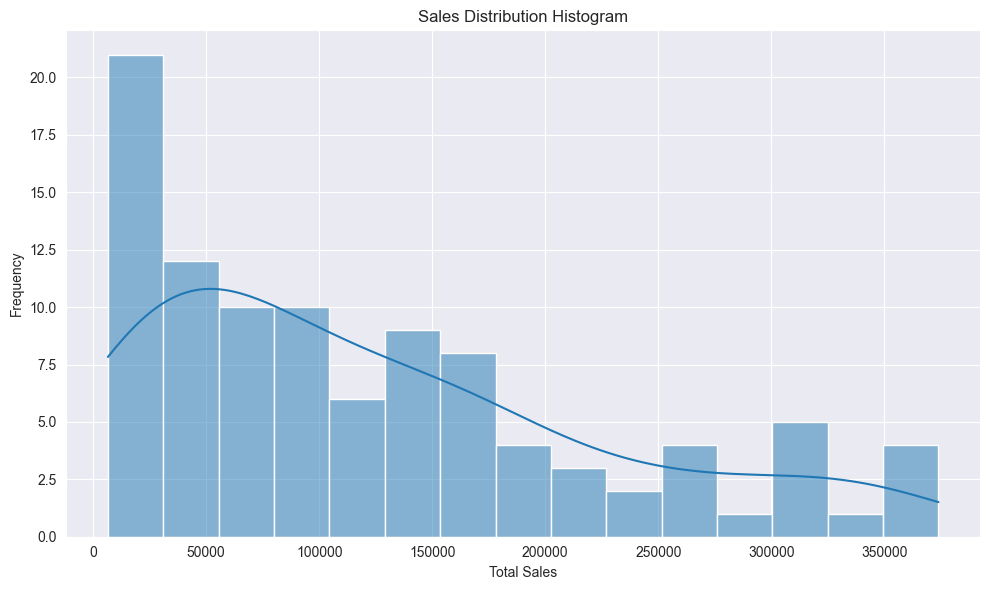

Shapiro Statistic: 0.8989
P-Value: 0.0000
Conclusion: Data is NOT Normally Distributed

DAY 3: CORRELATION ANALYSIS
             Quantity     Price  Total_Sales
Quantity     1.000000  0.008014     0.688107
Price        0.008014  1.000000     0.646131
Total_Sales  0.688107  0.646131     1.000000


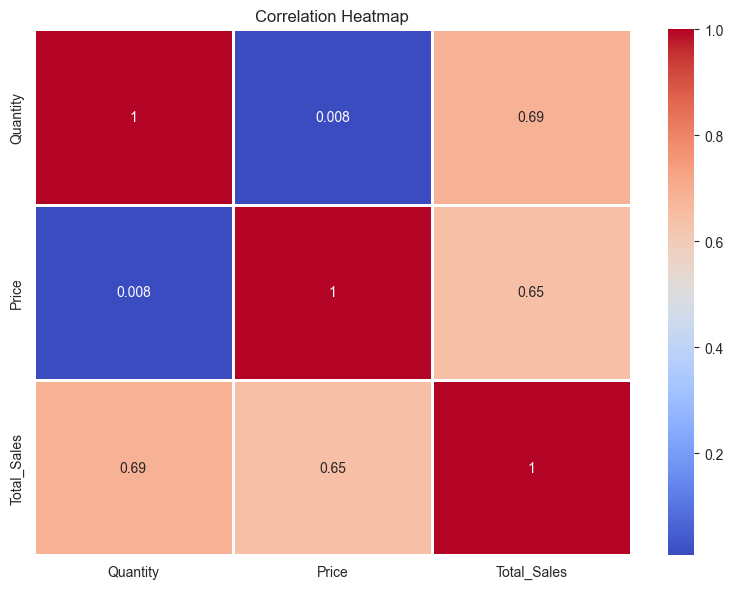


DAY 4: HYPOTHESIS TESTING

T-TEST
H0: East and West region sales are equal
H1: East and West region sales are different
T Statistic: 2.0202
P Value: 0.0496
Reject H0

ANOVA TEST
H0: All regions have same average sales
H1: At least one region differs
F Statistic: 2.1644
P Value: 0.0972
Fail to Reject H0

DAY 5: CONFIDENCE INTERVAL
Mean Sales: 123650.48
95% Confidence Interval: (103776.34767158539, 143524.6123284146)
Margin of Error: 19874.13


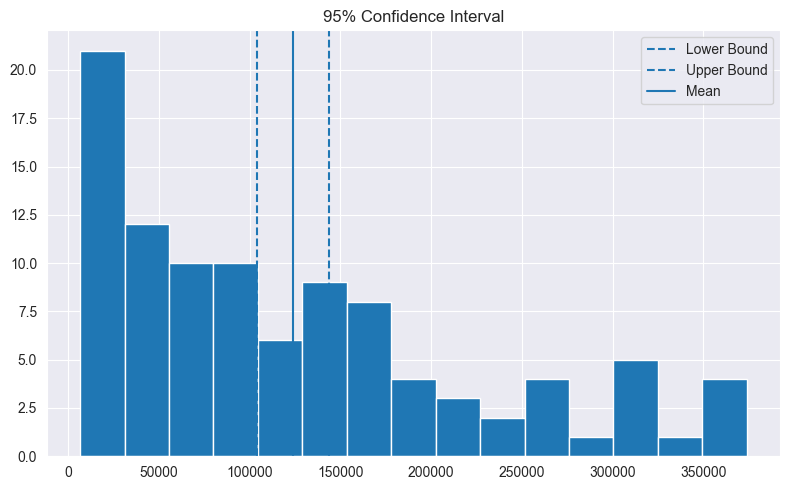


DAY 6: REGRESSION ANALYSIS
Intercept: -121682.21737545483
Coefficients: [2.64308402e+04 4.61062190e+00]
R-Squared: 0.8839073148081258


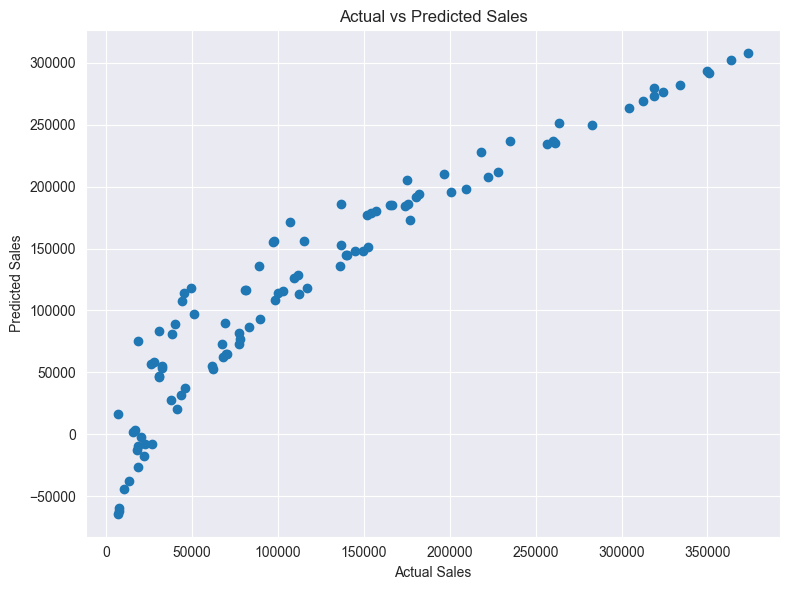


DAY 7: BUSINESS INSIGHTS

Top Products By Revenue
Product
Laptop        3889210
Tablet        2884340
Phone         2859394
Headphones    1384033
Monitor       1348071
Name: Total_Sales, dtype: int64

Top Regions By Revenue
Region
North    3983635
South    3737852
East     2519639
West     2123922
Name: Total_Sales, dtype: int64

ACTIONABLE RECOMMENDATIONS
1. Increase marketing investment for Laptop.
2. Expand business operations in North region.
3. Focus on high-value customers through loyalty programs.
4. Monitor low-performing products and improve sales strategies.
5. Use predictive analytics for future sales forecasting.


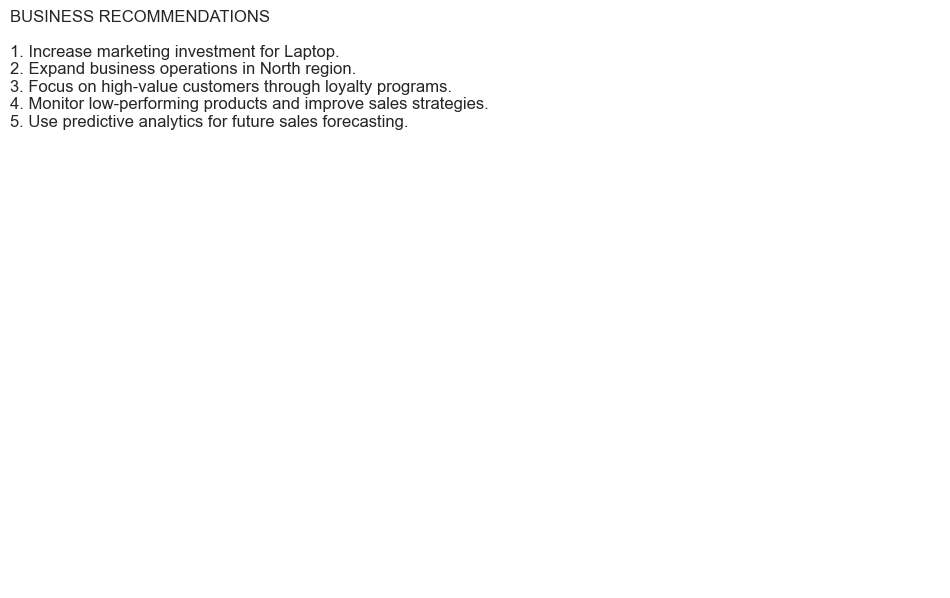


PROJECT COMPLETED SUCCESSFULLY
All visualizations saved in 'visualizations' folder


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, ttest_ind, f_oneway
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import os

# LOAD DATA

df = pd.read_csv("sales_data.csv")

df["Date"] = pd.to_datetime(df["Date"])

# CREATE FOLDER

os.makedirs("visualizations", exist_ok=True)

sns.set_style("darkgrid")

# DAY 1: DESCRIPTIVE STATISTICS

print("\n" + "=" * 60)
print("DAY 1: DESCRIPTIVE STATISTICS")
print("=" * 60)

mean_sales = df["Total_Sales"].mean()
median_sales = df["Total_Sales"].median()
mode_sales = df["Total_Sales"].mode()[0]
std_sales = df["Total_Sales"].std()
var_sales = df["Total_Sales"].var()

print(f"Mean Sales: {mean_sales:.2f}")
print(f"Median Sales: {median_sales:.2f}")
print(f"Mode Sales: {mode_sales}")
print(f"Standard Deviation: {std_sales:.2f}")
print(f"Variance: {var_sales:.2f}")

# DAY 2: DATA DISTRIBUTION ANALYSIS

print("\n" + "=" * 60)
print("DAY 2: DATA DISTRIBUTION ANALYSIS")
print("=" * 60)

plt.figure(figsize=(10, 6))

sns.histplot(
    df["Total_Sales"],
    bins=15,
    kde=True
)

plt.title("Sales Distribution Histogram")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "visualizations/histogram.png"
)

plt.show()

shapiro_stat, shapiro_p = shapiro(df["Total_Sales"])

print(f"Shapiro Statistic: {shapiro_stat:.4f}")
print(f"P-Value: {shapiro_p:.4f}")

if shapiro_p > 0.05:
    print("Conclusion: Data is Normally Distributed")
else:
    print("Conclusion: Data is NOT Normally Distributed")

# DAY 3: CORRELATION ANALYSIS

print("\n" + "=" * 60)
print("DAY 3: CORRELATION ANALYSIS")
print("=" * 60)

corr_matrix = df[
    ["Quantity", "Price", "Total_Sales"]
].corr(method="pearson")

print(corr_matrix)

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=1
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "visualizations/correlation_heatmap.png"
)

plt.show()

# DAY 4: HYPOTHESIS TESTING

print("\n" + "=" * 60)
print("DAY 4: HYPOTHESIS TESTING")
print("=" * 60)

east_sales = df[df["Region"] == "East"]["Total_Sales"]
west_sales = df[df["Region"] == "West"]["Total_Sales"]

t_stat, t_p = ttest_ind(
    east_sales,
    west_sales
)

print("\nT-TEST")
print("H0: East and West region sales are equal")
print("H1: East and West region sales are different")
print(f"T Statistic: {t_stat:.4f}")
print(f"P Value: {t_p:.4f}")

if t_p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

north_sales = df[df["Region"] == "North"]["Total_Sales"]
south_sales = df[df["Region"] == "South"]["Total_Sales"]

f_stat, anova_p = f_oneway(
    east_sales,
    west_sales,
    north_sales,
    south_sales
)

print("\nANOVA TEST")
print("H0: All regions have same average sales")
print("H1: At least one region differs")

print(f"F Statistic: {f_stat:.4f}")
print(f"P Value: {anova_p:.4f}")

if anova_p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

# DAY 5: CONFIDENCE INTERVAL

print("\n" + "=" * 60)
print("DAY 5: CONFIDENCE INTERVAL")
print("=" * 60)

sales = df["Total_Sales"]

mean = np.mean(sales)
sem = stats.sem(sales)

confidence_interval = stats.t.interval(
    confidence=0.95,
    df=len(sales) - 1,
    loc=mean,
    scale=sem
)

margin_error = confidence_interval[1] - mean

print(f"Mean Sales: {mean:.2f}")
print(f"95% Confidence Interval: {confidence_interval}")
print(f"Margin of Error: {margin_error:.2f}")

plt.figure(figsize=(8, 5))

plt.hist(
    sales,
    bins=15
)

plt.axvline(
    confidence_interval[0],
    linestyle="--",
    label="Lower Bound"
)

plt.axvline(
    confidence_interval[1],
    linestyle="--",
    label="Upper Bound"
)

plt.axvline(
    mean,
    label="Mean"
)

plt.title("95% Confidence Interval")

plt.legend()

plt.tight_layout()

plt.savefig(
    "visualizations/confidence_interval.png"
)

plt.show()

# DAY 6: REGRESSION ANALYSIS

print("\n" + "=" * 60)
print("DAY 6: REGRESSION ANALYSIS")
print("=" * 60)

X = df[["Quantity", "Price"]]
y = df["Total_Sales"]

model = LinearRegression()

model.fit(X, y)

predictions = model.predict(X)

r2 = r2_score(y, predictions)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("R-Squared:", r2)

plt.figure(figsize=(8, 6))

plt.scatter(
    y,
    predictions
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.tight_layout()

plt.savefig(
    "visualizations/regression_analysis.png"
)

plt.show()

# DAY 7: BUSINESS INSIGHTS

print("\n" + "=" * 60)
print("DAY 7: BUSINESS INSIGHTS")
print("=" * 60)

top_product = (
    df.groupby("Product")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

top_region = (
    df.groupby("Region")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("\nTop Products By Revenue")
print(top_product)

print("\nTop Regions By Revenue")
print(top_region)

best_product = top_product.index[0]
best_region = top_region.index[0]

recommendations = [
    f"Increase marketing investment for {best_product}.",
    f"Expand business operations in {best_region} region.",
    "Focus on high-value customers through loyalty programs.",
    "Monitor low-performing products and improve sales strategies.",
    "Use predictive analytics for future sales forecasting."
]

print("\nACTIONABLE RECOMMENDATIONS")

for i, recommendation in enumerate(recommendations, start=1):
    print(f"{i}. {recommendation}")

plt.figure(figsize=(12, 6))

plt.axis("off")

plt.text(
    0,
    1,
    "BUSINESS RECOMMENDATIONS\n\n" +
    "\n".join(
        [f"{i}. {r}" for i, r in enumerate(recommendations, start=1)]
    ),
    fontsize=12
)

plt.savefig(
    "visualizations/business_insights.png",
    bbox_inches="tight"
)

plt.show()

print("\n" + "=" * 60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("All visualizations saved in 'visualizations' folder")
print("=" * 60)